In [43]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import pymysql

# ==========================================
# 1. KHAI BÁO THÔNG TIN KẾT NỐI
# ==========================================
# Thông tin này dùng để mở cái kho 'kho_du_lieu'
USER = 'root'
PASSWORD = '123456'             # Mật khẩu bạn đã cài đặt
HOST = '127.0.0.1'
DATABASE = 'kho_du_lieu'        # Tên chính xác của Database chứa bảng

# ==========================================
# 2. TẠO ĐƯỜNG ỐNG KẾT NỐI TỪ PYTHON VÀO MYSQL
# ==========================================
chuoi_ket_noi = f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DATABASE}"
engine = create_engine(chuoi_ket_noi)

# ==========================================
# 3. KÉO BẢNG DỮ LIỆU SẠCH VỀ PYTHON
# ==========================================
print("Đang kết nối và kéo dữ liệu từ MySQL...")

try:
    # Lệnh SQL để lấy toàn bộ dữ liệu từ bảng hr_data_final
    cau_lenh_sql = "SELECT * FROM hr_data_final"
    
    # Dùng Pandas đọc dữ liệu qua đường ống engine
    df = pd.read_sql(cau_lenh_sql, con=engine)
    
    print("✅ ĐÃ KÉO DỮ LIỆU THÀNH CÔNG!")
    print(f"Tổng số dòng đang có trong Python: {len(df)} dòng")
    
    # Hiển thị thử 5 dòng đầu tiên để kiểm tra
    display(df.head())

    # ==========================================
    # 4. TẠO ĐIỂM LƯU TRỮ (CHECKPOINT) CHO EDA & POWER BI
    # ==========================================
    df.to_csv("Cleaned_HR_Data_EDA.csv", index=False, encoding='utf-8-sig')
    print("✅ Đã lưu thành công bản sao an toàn: Cleaned_HR_Data_EDA.csv")

except Exception as e:
    print("❌ Lỗi trong quá trình kéo dữ liệu:")
    print(e)

Đang kết nối và kéo dữ liệu từ MySQL...
✅ ĐÃ KÉO DỮ LIỆU THÀNH CÔNG!
Tổng số dòng đang có trong Python: 2357 dòng


,Employee ID,StartDate,start_date_parsed,years_of_service,tenure_group,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,...,Training Program Name,Training Type,Training Outcome,training_success,Training Duration(Days),Training Cost,Age,age_group,flag_under18_at_hire,flag_training_before_hire
0,3427,20-Sep-19,2019-09-20,6,5-9 yrs,Production Technician I,CCDR,Active,Contract,ZONE C,...,Leadership Development,Internal,Failed,0,2,606.11,50,50-59,0,0
1,3428,11-Feb-23,2023-02-11,3,2-4 yrs,Production Technician I,EW,Active,Contract,ZONE A,...,Customer Service,External,Incomplete,0,4,673.02,58,50-59,0,1
2,3429,10-Dec-18,2018-12-10,7,5-9 yrs,Area Sales Manager,PL,Active,Full-Time,ZONE B,...,Leadership Development,External,Failed,0,2,413.28,27,Under 30,0,0
3,3430,21-Jun-21,2021-06-21,4,2-4 yrs,Area Sales Manager,CCDR,Active,Contract,ZONE A,...,Project Management,External,Completed,1,3,663.78,23,Under 30,0,0
4,3431,29-Jun-19,2019-06-29,6,5-9 yrs,Area Sales Manager,TNS,Active,Contract,ZONE A,...,Technical Skills,External,Failed,0,5,399.03,50,50-59,0,0


✅ Đã lưu thành công bản sao an toàn: Cleaned_HR_Data_EDA.csv


### EDA

In [44]:
import pandas as pd              # xử lý dữ liệu
import numpy as np               # tính toán số học
import matplotlib.pyplot as plt  # vẽ biểu đồ cơ bản
import seaborn as sns            # vẽ biểu đồ đẹp hơn
import plotly.express as px      # biểu đồ tương tác

In [45]:
# 1. Kiểm tra kích thước và trùng lặp dòng (Duplicate Rows)
num_rows, num_cols = df.shape
duplicate_count = df.duplicated().sum()

print("====== KIỂM TRA TỔNG QUAN ======")
print(f"- Số lượng dòng dữ liệu (Rows): {num_rows}")
print(f"- Số lượng cột dữ liệu (Columns): {num_cols}")
print(f"- Số dòng bị trùng lặp hoàn toàn: {duplicate_count}")

if duplicate_count > 0:
    print("⚠️ Cảnh báo: Có dữ liệu trùng lặp. Bạn có thể cần cân nhắc dùng `df.drop_duplicates()`")
else:
    print("✅ Tuyệt vời: Không có dòng dữ liệu nào bị trùng lặp.")

====== KIỂM TRA TỔNG QUAN ======
- Số lượng dòng dữ liệu (Rows): 2357
- Số lượng cột dữ liệu (Columns): 38
- Số dòng bị trùng lặp hoàn toàn: 0
✅ Tuyệt vời: Không có dòng dữ liệu nào bị trùng lặp.


In [46]:
# 2. Tạo một DataFrame tổng hợp thông tin từng cột để dễ quan sát
checking_summary = pd.DataFrame({
    'Kiểu dữ liệu (Dtype)': df.dtypes,
    'Số lượng ô trống (Null)': df.isnull().sum(),
    'Tỷ lệ trống (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Số lượng giá trị duy nhất (Unique)': df.nunique()
})

print("====== BẢNG BÁO CÁO CHI TIẾT TỪNG BIẾN ======")
display(checking_summary)

====== BẢNG BÁO CÁO CHI TIẾT TỪNG BIẾN ======


,Kiểu dữ liệu (Dtype),Số lượng ô trống (Null),Tỷ lệ trống (%),Số lượng giá trị duy nhất (Unique)
Employee ID,int64,0,0.0,2357
StartDate,str,0,0.0,1344
start_date_parsed,object,0,0.0,1344
years_of_service,int64,0,0.0,6
tenure_group,str,0,0.0,2
Title,str,0,0.0,31
BusinessUnit,str,0,0.0,10
EmployeeStatus,str,0,0.0,2
EmployeeType,str,0,0.0,3
PayZone,str,0,0.0,3


In [47]:
print("====== KIỂM TRA SƠ BỘ GIÁ TRỊ BẤT THƯỜNG ======")

# Kiểm tra các biến số quan trọng xem có bị âm hoặc bất thường không
num_cols_to_check = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Employee ID' in num_cols_to_check: 
    num_cols_to_check.remove('Employee ID')

anomalies_found = False
for col in num_cols_to_check:
    min_val = df[col].min()
    max_val = df[col].max()
    
    # Ví dụ kiểm tra xem chi phí hoặc tuổi có bị nhỏ hơn 0 không
    if min_val < 0:
        print(f"⚠️ Cảnh báo: Cột '{col}' chứa giá trị âm (Min = {min_val}). Hãy kiểm tra lại logic!")
        anomalies_found = True

# Kiểm tra xem có cột chữ nào chứa khoảng trắng vô nghĩa không (gây lệch khi Groupby)
string_cols = df.select_dtypes(include=['object']).columns
for col in string_cols:
    # Kiểm tra xem có ô nào chỉ chứa toàn dấu cách không
    empty_spaces = df[col].astype(str).str.isspace().sum()
    if empty_spaces > 0:
        print(f"⚠️ Cảnh báo: Cột '{col}' chứa {empty_spaces} ô chỉ toàn ký tự khoảng trắng.")
        anomalies_found = True

if not anomalies_found:
    print("✅ Sơ bộ: Miền giá trị của các biến số và biến chữ nằm trong phạm vi hợp lý.")

====== KIỂM TRA SƠ BỘ GIÁ TRỊ BẤT THƯỜNG ======
✅ Sơ bộ: Miền giá trị của các biến số và biến chữ nằm trong phạm vi hợp lý.


C:\Users\Admin\AppData\Local\Temp\ipykernel_9088\1206527922.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=['object']).columns


### Thống kê mô tả 

In [48]:
# Tách các cột số (loại bỏ cột định danh Employee ID)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Employee ID' in num_cols:
    num_cols.remove('Employee ID')

print("====== BẢNG THỐNG KÊ MÔ TẢ BIẾN SỐ ======")
# Lấy bảng thống kê cơ bản và xoay dòng thành cột (.T) để dễ nhìn
num_desc = df[num_cols].describe().T

# Bổ sung chỉ số Skewness (Độ lệch): 
# > 0: lệch phải (đuôi dài bên phải), < 0: lệch trái, ~ 0: đối xứng chuẩn
num_desc['skewness (Độ lệch)'] = df[num_cols].skew()

# Làm tròn 2 chữ số thập phân và hiển thị dưới dạng bảng đẹp
display(num_desc.round(2))

====== BẢNG THỐNG KÊ MÔ TẢ BIẾN SỐ ======


,count,mean,std,min,25%,50%,75%,max,skewness (Độ lệch)
years_of_service,2357.0,4.86,1.47,2.00,4.00,5.00,6.00,7.00,-0.05
Current Employee Rating,2357.0,2.97,1.01,1.00,2.00,3.00,3.00,5.00,0.07
Engagement Score,2357.0,2.96,1.44,1.00,2.00,3.00,4.00,5.00,0.04
Satisfaction Score,2357.0,3.04,1.40,1.00,2.00,3.00,4.00,5.00,-0.07
Work-Life Balance Score,2357.0,3.00,1.41,1.00,2.00,3.00,4.00,5.00,0.00
training_success,2357.0,0.51,0.50,0.00,0.00,1.00,1.00,1.00,-0.04
Training Duration(Days),2357.0,2.97,1.42,1.00,2.00,3.00,4.00,5.00,0.03
Training Cost,2357.0,559.94,263.84,100.04,326.37,573.29,788.64,999.97,-0.08
Age,2357.0,44.23,14.73,17.00,31.00,44.00,58.00,69.00,0.01
flag_under18_at_hire,2357.0,0.00,0.05,0.00,0.00,0.00,0.00,1.00,21.66


### Biến phân loại

In [49]:
# Tách các cột chữ
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("====== BẢNG THỐNG KÊ MÔ TẢ BIẾN CHỮ ======")
cat_desc = df[cat_cols].describe().T

# Tính thêm tỷ lệ phần trăm (%) của nhóm chiếm đa số (top) so với tổng số nhân viên
cat_desc['Tỷ lệ nhóm top (%)'] = ((cat_desc['freq'] / cat_desc['count']) * 100).round(2)

display(cat_desc)

====== BẢNG THỐNG KÊ MÔ TẢ BIẾN CHỮ ======


C:\Users\Admin\AppData\Local\Temp\ipykernel_9088\2100954803.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


,count,unique,top,freq,Tỷ lệ nhóm top (%)
StartDate,2357,1344,04-Mar-22,7,0.3
start_date_parsed,2357,1344,2022-03-04,7,0.3
tenure_group,2357,2,5-9 yrs,1350,57.28
Title,2357,31,Production Technician I,1026,43.53
BusinessUnit,2357,10,TNS,240,10.18
EmployeeStatus,2357,2,Active,2038,86.47
EmployeeType,2357,3,Full-Time,821,34.83
PayZone,2357,3,ZONE A,847,35.94
EmployeeClassificationType,2357,3,Full-Time,807,34.24
DepartmentType,2357,6,Production,1576,66.86


### Tỷ lệ phần trăm của các biến cốt lõi

In [50]:
# Danh sách các biến phân loại quan trọng cần đào sâu cơ cấu %
core_cat_cols = ['EmployeeStatus', 'EmployeeType', 'GenderCode', 'Performance Score', 'Training Outcome']

print("====== CƠ CẤU CHI TIẾT CÁC BIẾN QUAN TRỌNG ======")
for col in core_cat_cols:
    print(f"\n🔹 Biến: {col}")
    # Lập bảng tần suất và tỷ lệ phần trăm
    freq_table = pd.DataFrame({
        'Số lượng (Count)': df[col].value_counts(),
        'Tỷ lệ (%):': (df[col].value_counts(normalize=True) * 100).round(2)
    })
    display(freq_table)

====== CƠ CẤU CHI TIẾT CÁC BIẾN QUAN TRỌNG ======

🔹 Biến: EmployeeStatus


,Số lượng (Count),Tỷ lệ (%):
EmployeeStatus,,
Active,2038,86.47
Terminated,319,13.53



🔹 Biến: EmployeeType


,Số lượng (Count),Tỷ lệ (%):
EmployeeType,,
Full-Time,821,34.83
Contract,790,33.52
Part-Time,746,31.65



🔹 Biến: GenderCode


,Số lượng (Count),Tỷ lệ (%):
GenderCode,,
Female,1310,55.58
Male,1047,44.42



🔹 Biến: Performance Score


,Số lượng (Count),Tỷ lệ (%):
Performance Score,,
Fully meets,1865,79.13
Exceeds,291,12.35
Needs improvement,123,5.22
Pip,78,3.31



🔹 Biến: Training Outcome


,Số lượng (Count),Tỷ lệ (%):
Training Outcome,,
Incomplete,610,25.88
Completed,609,25.84
Passed,595,25.24
Failed,543,23.04


### Thống kê mô tả theo từng nhóm

In [51]:
print("====== BẢNG THỐNG KÊ TRUNG BÌNH THEO PHÒNG BAN ======")

# Gom nhóm theo Phòng ban và tính trung bình các chỉ số quan trọng
dept_summary = df.groupby('DepartmentType').agg({
    'Employee ID': 'count',               # Đếm số nhân sự mỗi phòng
    'Engagement Score': 'mean',           # Điểm gắn kết trung bình
    'Satisfaction Score': 'mean',         # Điểm hài lòng trung bình
    'Work-Life Balance Score': 'mean',    # Điểm cân bằng cuộc sống trung bình
    'Training Cost': 'mean'               # Chi phí đào tạo trung bình
}).rename(columns={'Employee ID': 'Số lượng nhân sự'}).round(2)

# Sắp xếp theo phòng ban có mức độ gắn kết từ cao xuống thấp
display(dept_summary.sort_values(by='Engagement Score', ascending=False))

====== BẢNG THỐNG KÊ TRUNG BÌNH THEO PHÒNG BAN ======


,Số lượng nhân sự,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Cost
DepartmentType,,,,,
Executive office,23,3.30,3.13,3.22,571.20
It/is,344,3.06,3.05,2.99,564.23
Software engineering,92,2.97,3.10,2.95,576.26
Sales,257,2.96,3.09,3.03,548.60
Production,1576,2.93,3.04,2.98,560.71
Admin offices,65,2.88,2.69,3.15,536.24


## Phân phối theo từng biến

histogram cho các biến số

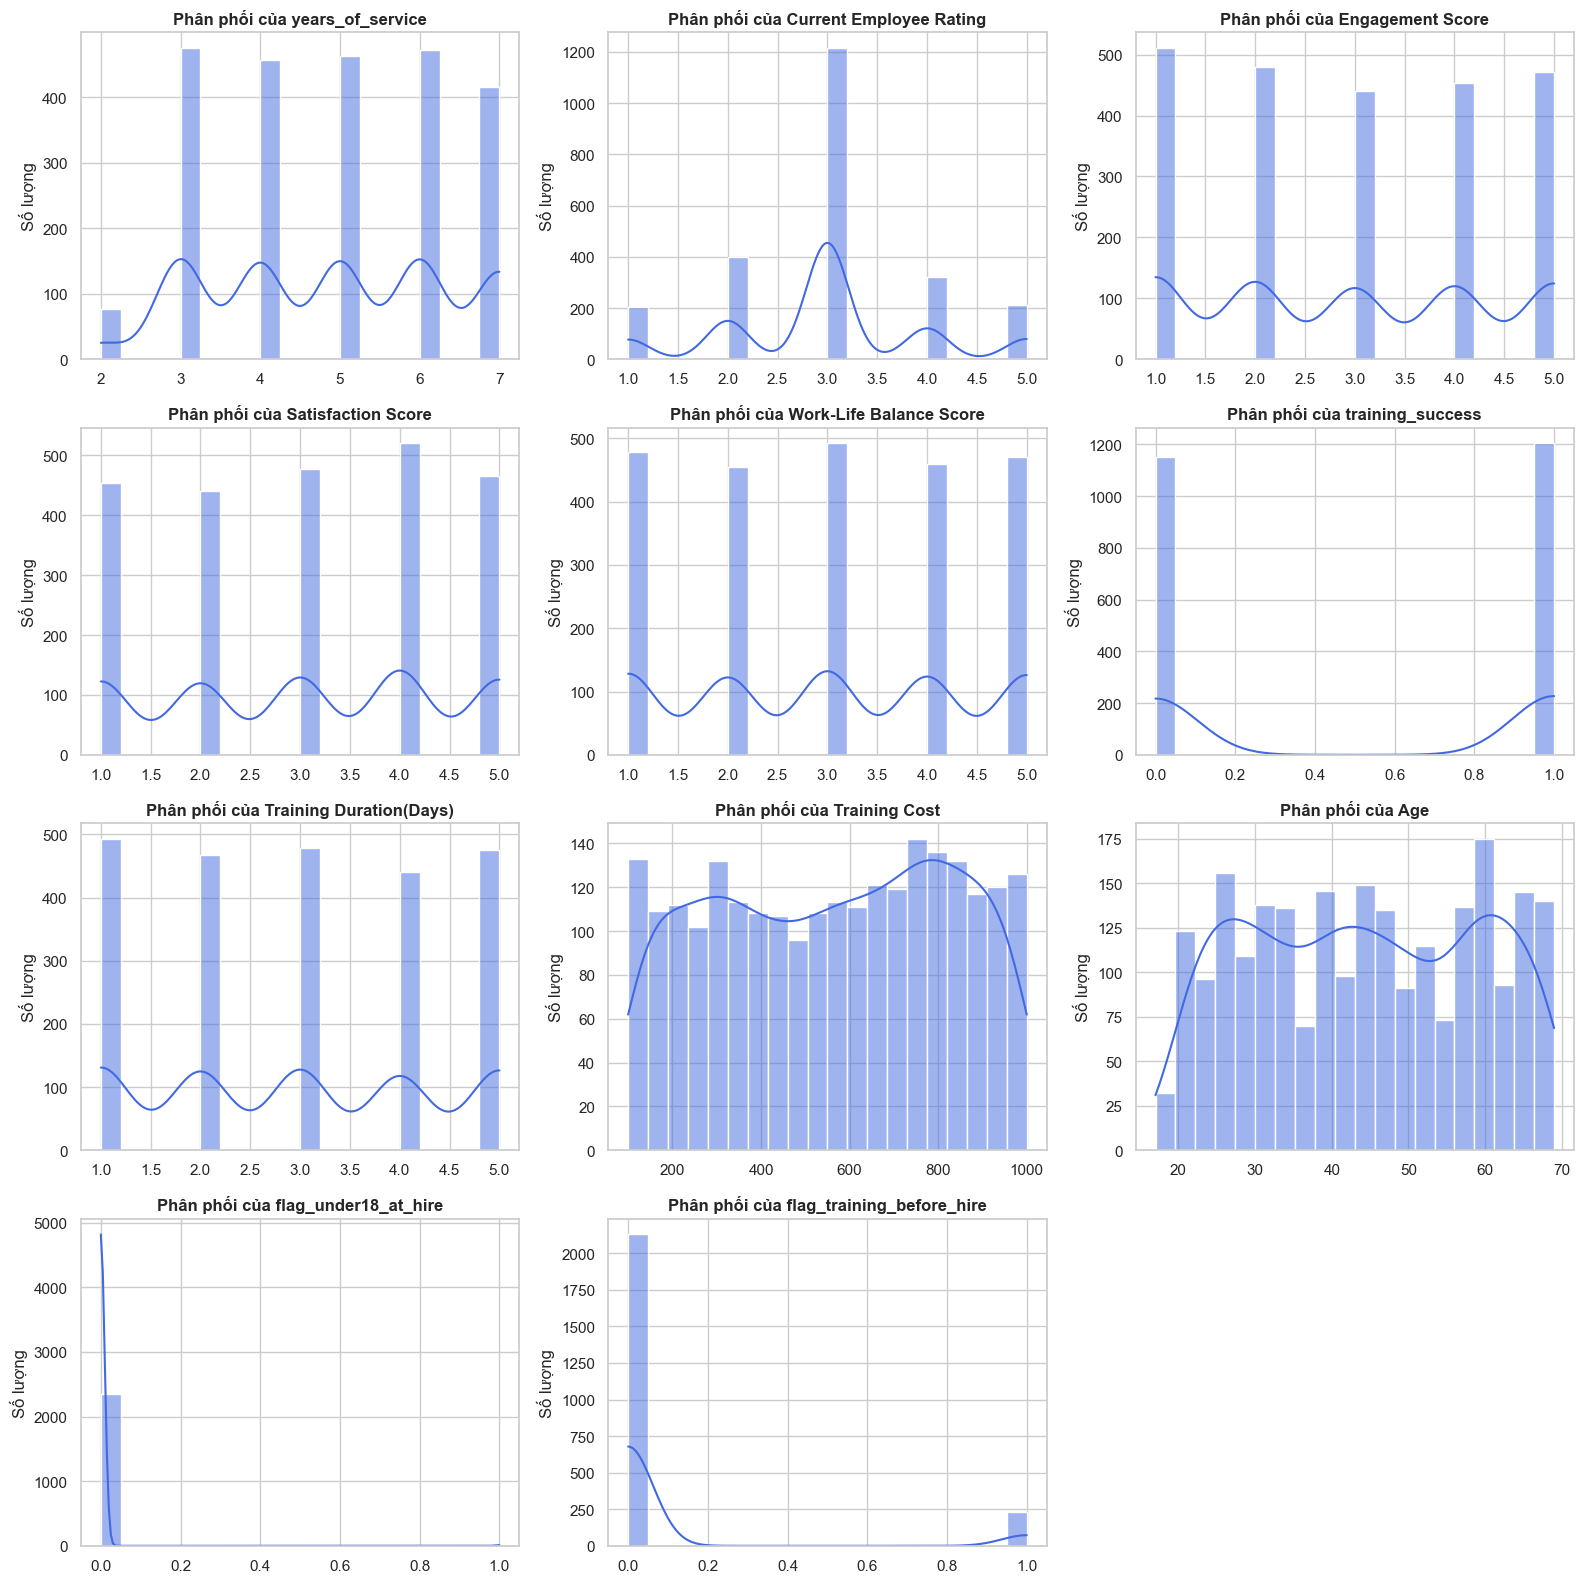

In [52]:
import math

# Lọc các biến số và loại bỏ cột ID
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Employee ID' in num_cols:
    num_cols.remove('Employee ID')

# Thiết lập kích thước lưới động
n_cols = len(num_cols)
n_grid_cols = 3
n_grid_rows = math.ceil(n_cols / n_grid_cols)

fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=(16, 4 * n_grid_rows))
axes = axes.flatten() # Trải phẳng mảng axes để dễ lặp

# Vẽ biểu đồ cho từng biến
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='royalblue', bins=20)
    axes[i].set_title(f'Phân phối của {col}', fontweight='bold')
    axes[i].set_ylabel('Số lượng')
    axes[i].set_xlabel('')

# Xóa các ô trống (nếu số lượng biến không chia hết cho 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Biến chữ

C:\Users\Admin\AppData\Local\Temp\ipykernel_9088\3062479952.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()
C:\Users\Admin\AppData\Local\Temp\ipykernel_9088\3062479952.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=order, ax=axes[i], palette='Set2')
C:\Users\Admin\AppData\Local\Temp\ipykernel_9088\3062479952.py:20: FutureWarning: 



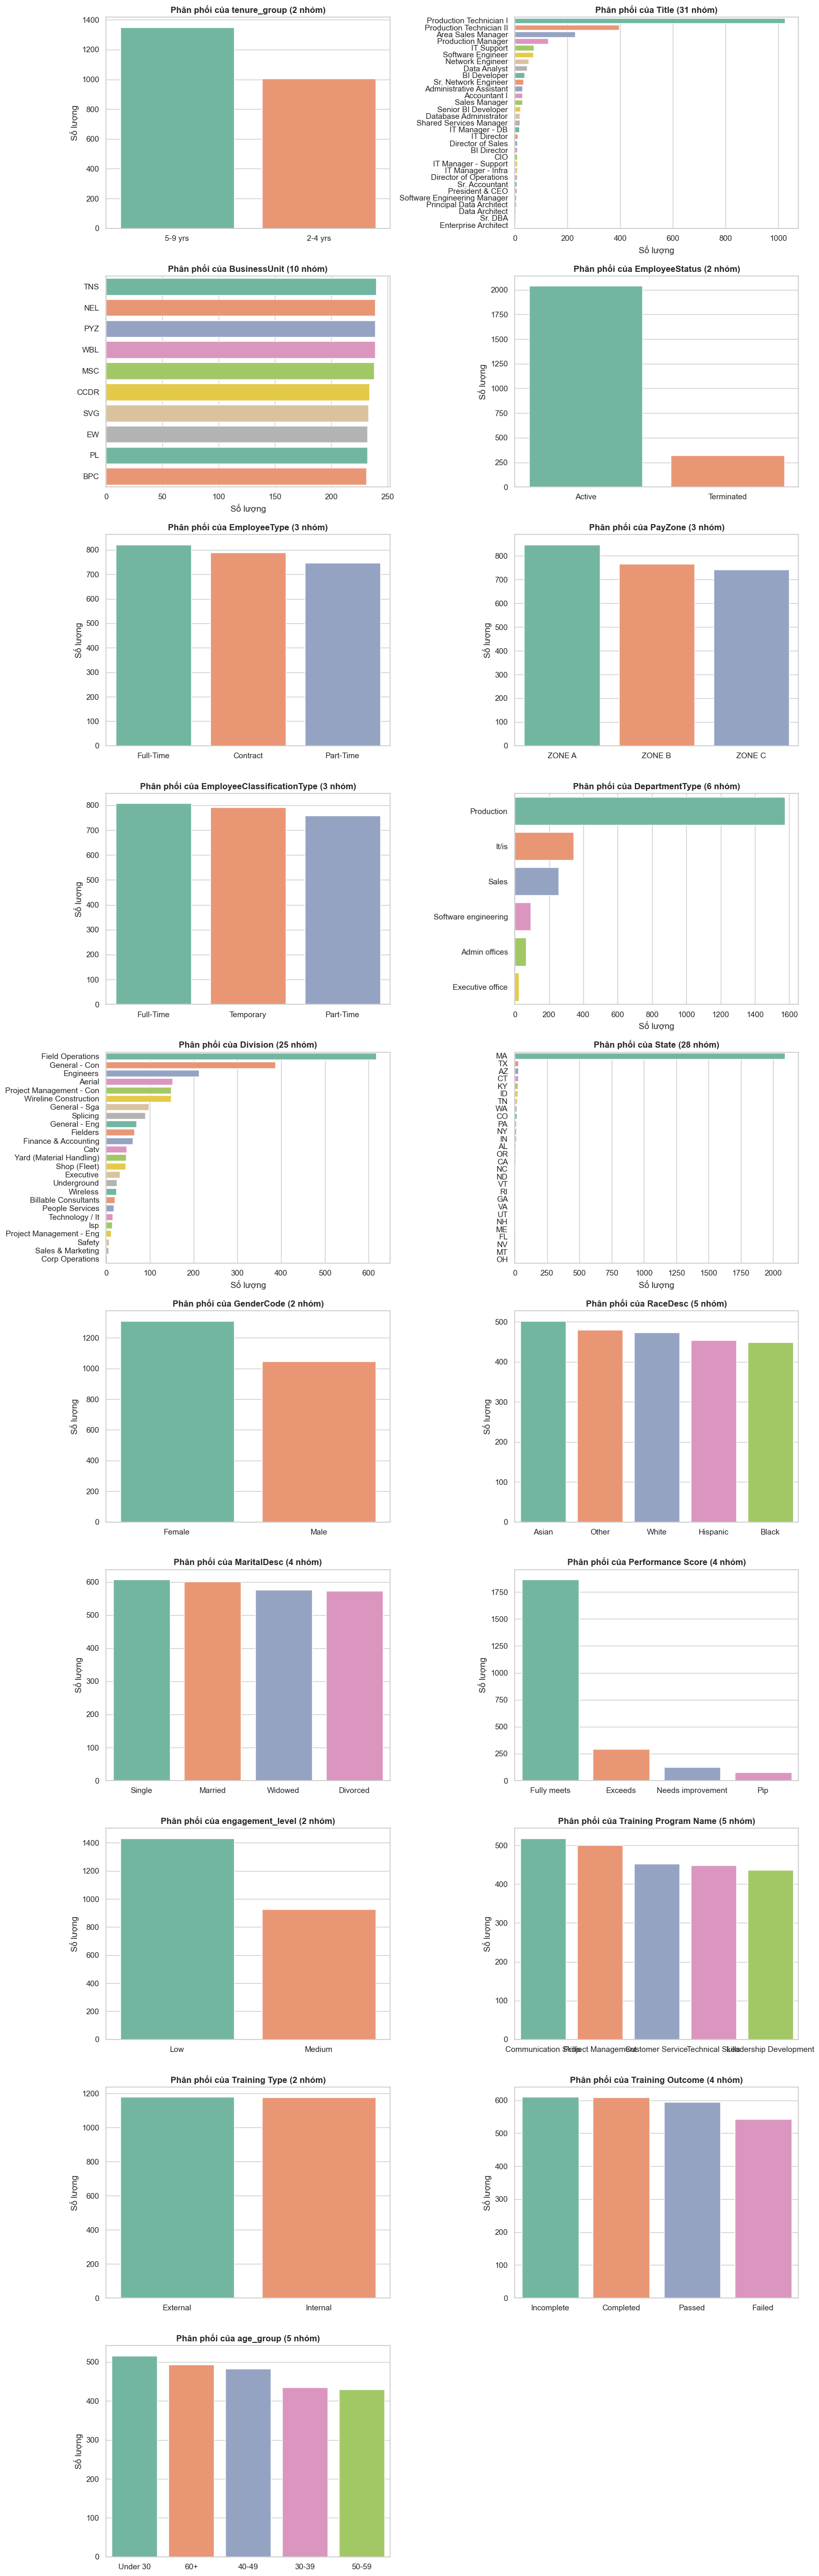

In [53]:
# Lọc các biến phân loại
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Loại bỏ các cột ngày tháng hoặc biến có quá nhiều nhóm (trên 35 nhóm) để không làm sập biểu đồ
clean_cat_cols = [col for col in cat_cols if 1 < df[col].nunique() <= 35]

n_cols_cat = len(clean_cat_cols)
n_grid_cols_cat = 2
n_grid_rows_cat = math.ceil(n_cols_cat / n_grid_cols_cat)

fig, axes = plt.subplots(n_grid_rows_cat, n_grid_cols_cat, figsize=(16, 5 * n_grid_rows_cat))
axes = axes.flatten()

for i, col in enumerate(clean_cat_cols):
    # Sắp xếp nhóm từ cao xuống thấp
    order = df[col].value_counts().index
    
    # Biến có > 5 nhóm thì vẽ ngang, <= 5 nhóm thì vẽ dọc
    if df[col].nunique() > 5:
        sns.countplot(y=df[col], order=order, ax=axes[i], palette='Set2')
        axes[i].set_xlabel('Số lượng')
        axes[i].set_ylabel('')
    else:
        sns.countplot(x=df[col], order=order, ax=axes[i], palette='Set2')
        axes[i].set_ylabel('Số lượng')
        axes[i].set_xlabel('')
        
    axes[i].set_title(f'Phân phối của {col} ({df[col].nunique()} nhóm)', fontweight='bold')

# Xóa các khung hình trống dư thừa
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Bổ sung kiểm tra giá trị ngoại lai

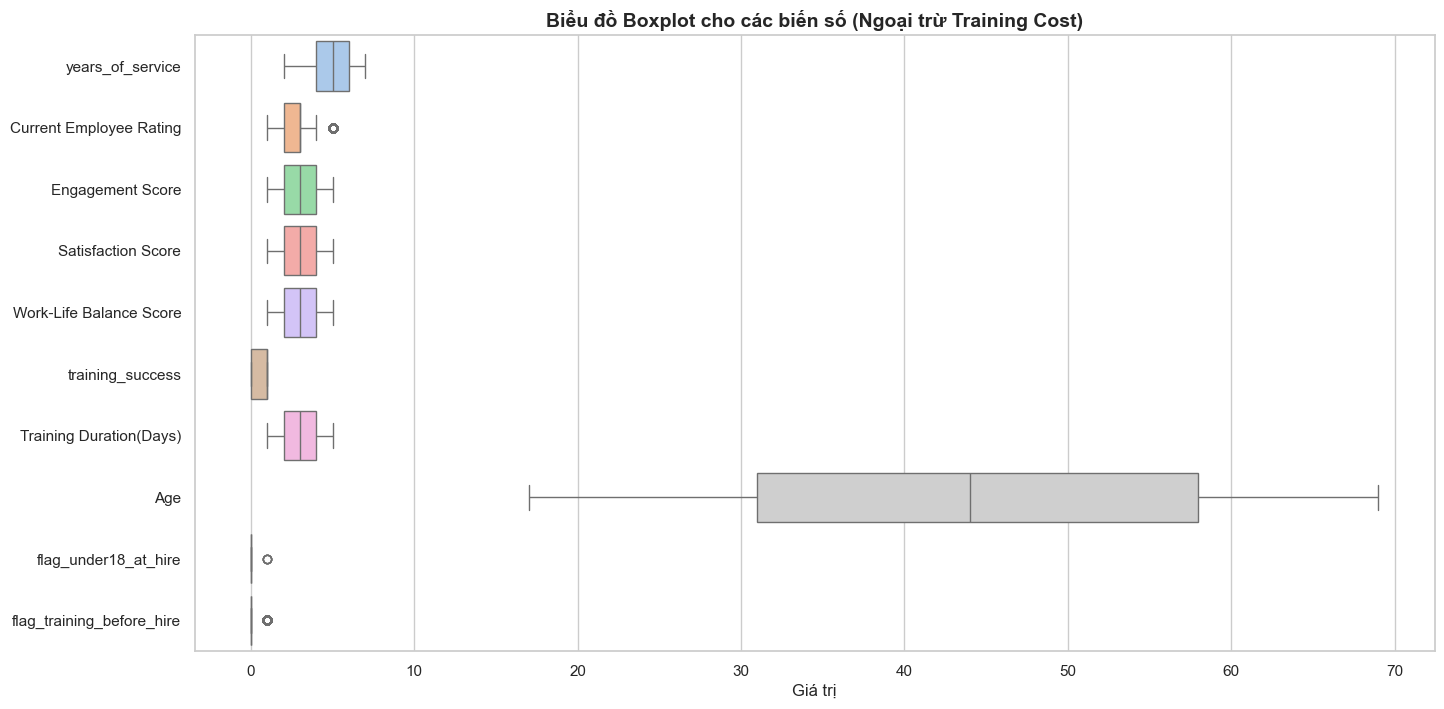

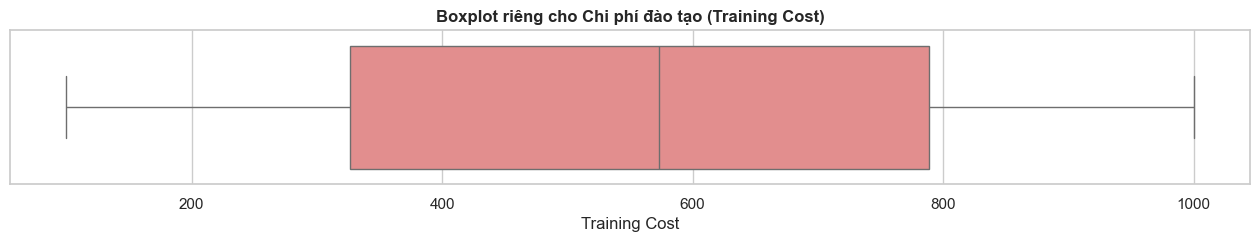

In [54]:
plt.figure(figsize=(16, 8))
# Tự động chuẩn hóa dữ liệu để vẽ chung trên cùng 1 thang đo, hoặc vẽ các biến có thang đo tương đồng
# Ở đây ta ưu tiên vẽ các biến có giá trị không quá cách biệt để dễ nhìn (bỏ Training Cost vì nó lên tới hàng ngàn)
box_cols = [col for col in num_cols if col != 'Training Cost']

sns.boxplot(data=df[box_cols], orient="h", palette="pastel")
plt.title("Biểu đồ Boxplot cho các biến số (Ngoại trừ Training Cost)", fontweight='bold', fontsize=14)
plt.xlabel("Giá trị")
plt.show()

# Vẽ riêng Boxplot cho Training Cost vì thang đo khác biệt
plt.figure(figsize=(16, 2))
sns.boxplot(x=df['Training Cost'], color='lightcoral')
plt.title("Boxplot riêng cho Chi phí đào tạo (Training Cost)", fontweight='bold', fontsize=12)
plt.show()

### Phân tích mối quan hệ giữa các biến

Phân tích Tương quan các biến định lượng

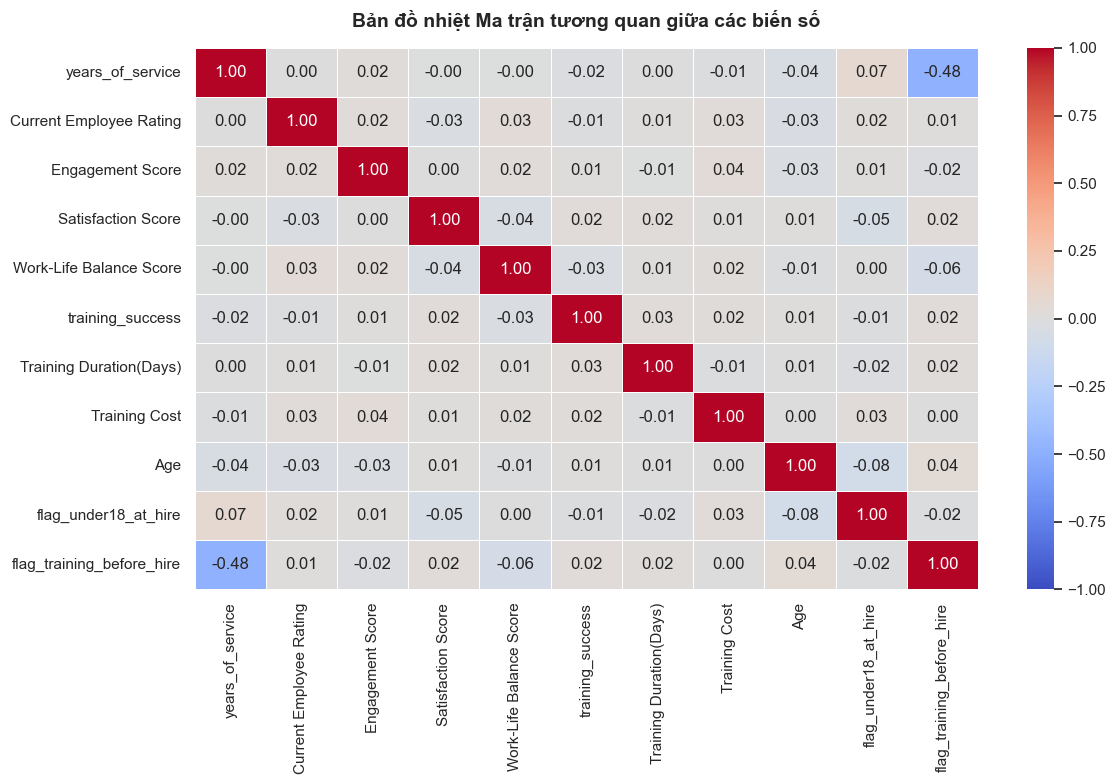

In [55]:
# Lọc các biến số và bỏ Employee ID (nếu có)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Employee ID' in num_cols:
    num_cols.remove('Employee ID')

# Tính toán ma trận tương quan (Pearson)
corr_matrix = df[num_cols].corr()

# Thiết lập kích thước khung hình rộng rãi
plt.figure(figsize=(12, 8))

# Vẽ Heatmap toàn phần (bỏ thuộc tính mask)
sns.heatmap(corr_matrix, 
            annot=True,              # Hiển thị số liệu trên từng ô
            cmap='coolwarm',         # Thang màu: Đỏ (đồng biến) - Xanh (nghịch biến)
            fmt=".2f",               # Làm tròn 2 chữ số thập phân
            linewidths=0.5,          # Đường viền giữa các ô cho dễ nhìn
            vmin=-1, vmax=1)         # Cố định thang đo từ -1 đến 1

plt.title('Bản đồ nhiệt Ma trận tương quan giữa các biến số', fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### Biến phân loại tác động lên biến số

C:\Users\Admin\AppData\Local\Temp\ipykernel_9088\788016917.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DepartmentType', y='Engagement Score', data=df, palette='Set3')


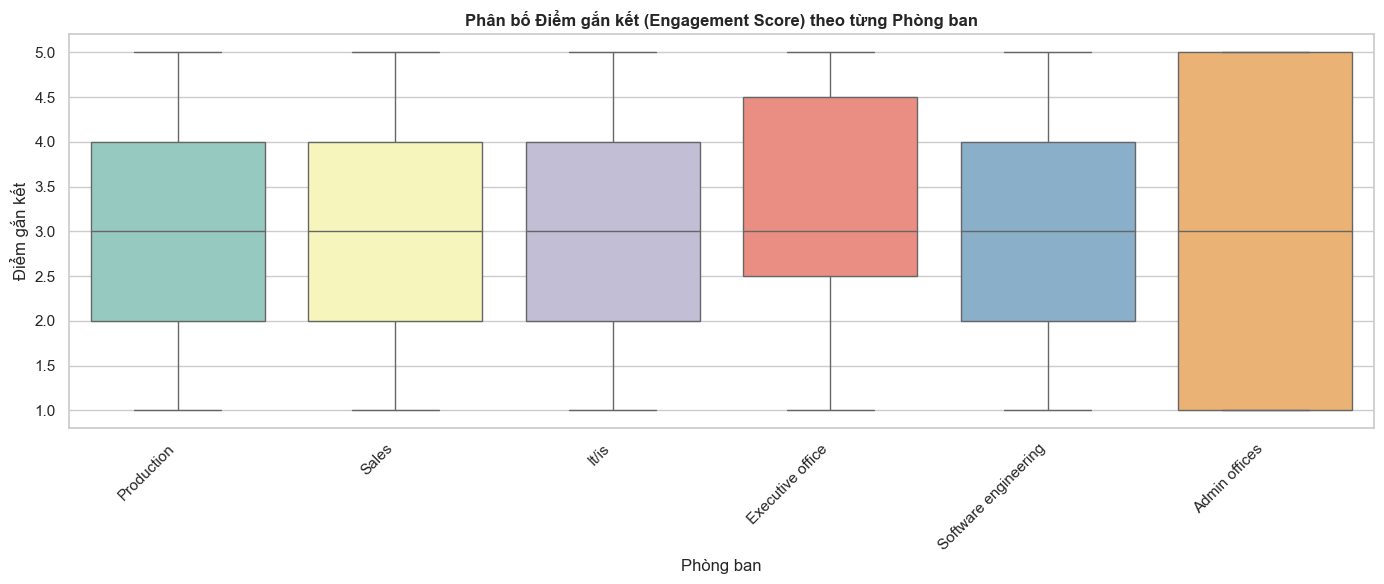

C:\Users\Admin\AppData\Local\Temp\ipykernel_9088\788016917.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='GenderCode', y='Training Cost', data=df, estimator=np.mean, errorbar=('ci', 95), palette='pastel')


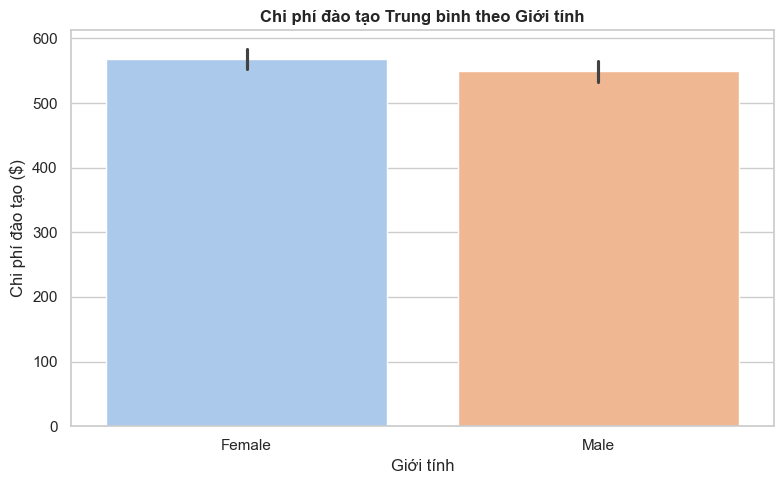

In [56]:
# Ví dụ 1: Điểm gắn kết (Engagement Score) có khác biệt giữa các Phòng ban không?
plt.figure(figsize=(14, 6))
sns.boxplot(x='DepartmentType', y='Engagement Score', data=df, palette='Set3')
plt.title('Phân bố Điểm gắn kết (Engagement Score) theo từng Phòng ban', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Điểm gắn kết')
plt.xlabel('Phòng ban')
plt.tight_layout()
plt.show()

# Ví dụ 2: Chi phí đào tạo giữa Nam và Nữ có chênh lệch không?
plt.figure(figsize=(8, 5))
sns.barplot(x='GenderCode', y='Training Cost', data=df, estimator=np.mean, errorbar=('ci', 95), palette='pastel')
plt.title('Chi phí đào tạo Trung bình theo Giới tính', fontweight='bold')
plt.ylabel('Chi phí đào tạo ($)')
plt.xlabel('Giới tính')
plt.tight_layout()
plt.show()

Mối quan hệ giữa 2 biến phân loại 

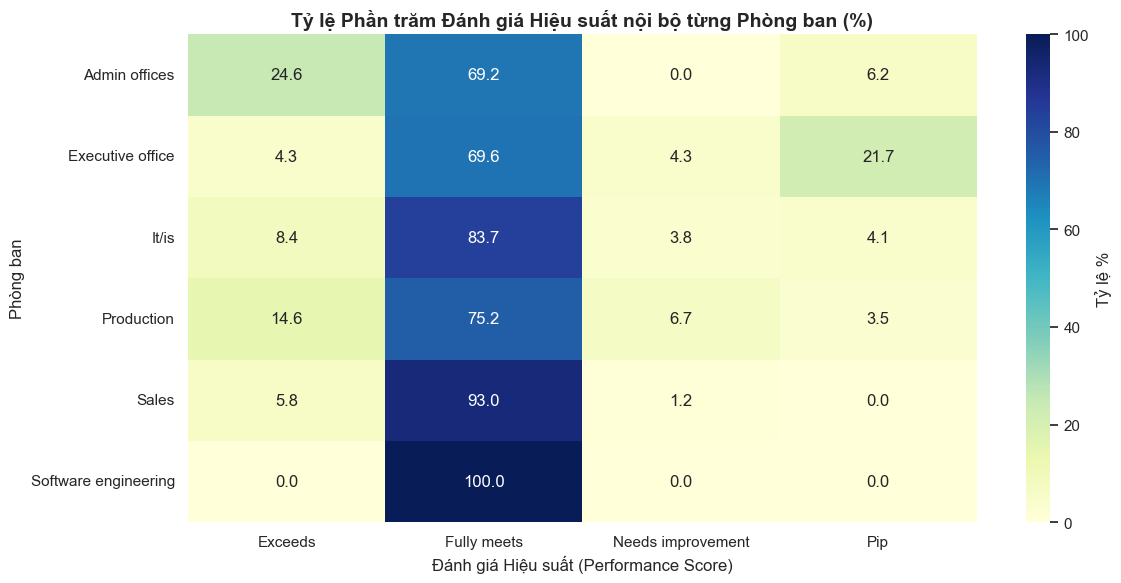

In [57]:
# Tạo bảng chéo: Tính tỷ lệ % Hiệu suất công việc (Performance Score) trong từng Phòng ban
crosstab_data = pd.crosstab(df['DepartmentType'], df['Performance Score'], normalize='index') * 100

plt.figure(figsize=(12, 6))
# Sử dụng cmap='Blues' hoặc 'YlGnBu' để làm nổi bật các ô có tỷ lệ % cao
sns.heatmap(crosstab_data, annot=True, cmap='YlGnBu', fmt=".1f", cbar_kws={'label': 'Tỷ lệ %'})
plt.title('Tỷ lệ Phần trăm Đánh giá Hiệu suất nội bộ từng Phòng ban (%)', fontweight='bold', fontsize=14)
plt.ylabel('Phòng ban')
plt.xlabel('Đánh giá Hiệu suất (Performance Score)')
plt.tight_layout()
plt.show()

Trực quan hóa đa chiều 

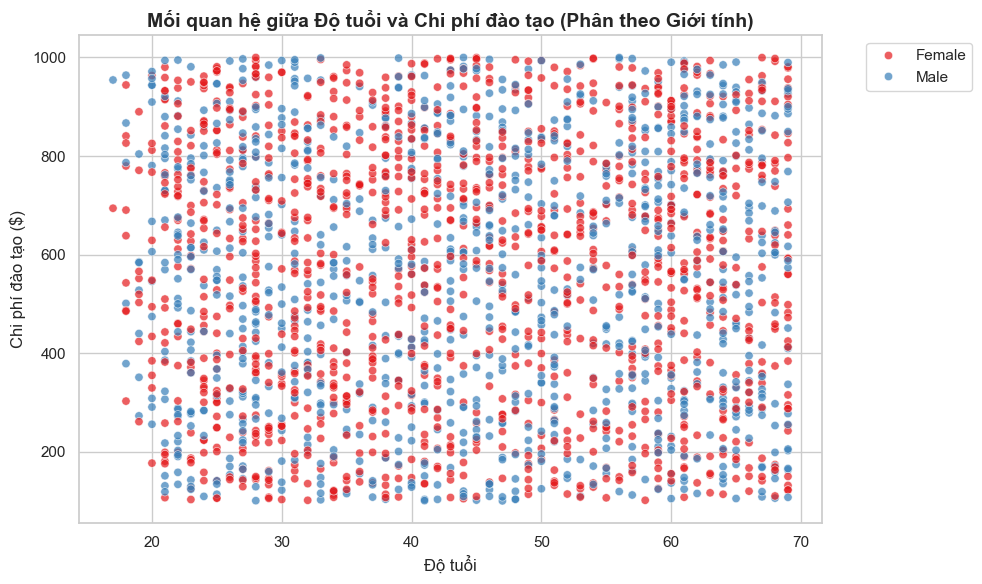

In [58]:
plt.figure(figsize=(10, 6))

# X=Tuổi, Y=Chi phí, Hue(Màu sắc)=Giới tính
sns.scatterplot(x='Age', y='Training Cost', hue='GenderCode', data=df, alpha=0.7, palette='Set1')
plt.title('Mối quan hệ giữa Độ tuổi và Chi phí đào tạo (Phân theo Giới tính)', fontweight='bold', fontsize=14)
plt.xlabel('Độ tuổi')
plt.ylabel('Chi phí đào tạo ($)')

# Đặt chú thích (Legend) ra bên ngoài biểu đồ cho gọn
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Phân tích theo nhóm 

In [59]:
# 1. Phân tích theo Phòng ban (DepartmentType)
print("--- THỐNG KÊ THEO PHÒNG BAN ---")
dept_stats = df.groupby('DepartmentType').agg(
    Số_lượng_NV=('Employee ID', 'count'),                     # Đếm số nhân viên
    Rating_Trung_bình=('Current Employee Rating', 'mean'),    # Điểm đánh giá trung bình
    Tổng_Chi_phí_Đào_tạo=('Training Cost', 'sum')             # Tổng tiền đào tạo
).reset_index()

# Sắp xếp theo Rating giảm dần để xem phòng nào làm việc tốt nhất
dept_stats = dept_stats.sort_values(by='Rating_Trung_bình', ascending=False)
display(dept_stats)

print("\n--- THỐNG KÊ THEO GIỚI TÍNH ---")
# 2. Phân tích theo Giới tính (GenderCode)
gender_stats = df.groupby('GenderCode').agg(
    Điểm_Gắn_kết_Trung_bình=('Engagement Score', 'mean'),
    Điểm_Hài_lòng_Trung_bình=('Satisfaction Score', 'mean')
).reset_index()
display(gender_stats)

--- THỐNG KÊ THEO PHÒNG BAN ---


,DepartmentType,Số_lượng_NV,Rating_Trung_bình,Tổng_Chi_phí_Đào_tạo
0,Admin offices,65,3.030769,34855.30
3,Production,1576,2.986675,883678.40
2,It/is,344,2.959302,194094.39
5,Software engineering,92,2.934783,53015.86
4,Sales,257,2.914397,140989.47
1,Executive office,23,2.782609,13137.65



--- THỐNG KÊ THEO GIỚI TÍNH ---


,GenderCode,Điểm_Gắn_kết_Trung_bình,Điểm_Hài_lòng_Trung_bình
0,Female,2.940458,3.034351
1,Male,2.974212,3.053486


C:\Users\Admin\AppData\Local\Temp\ipykernel_9088\4029654662.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_9088\4029654662.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_9088\4029654662.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


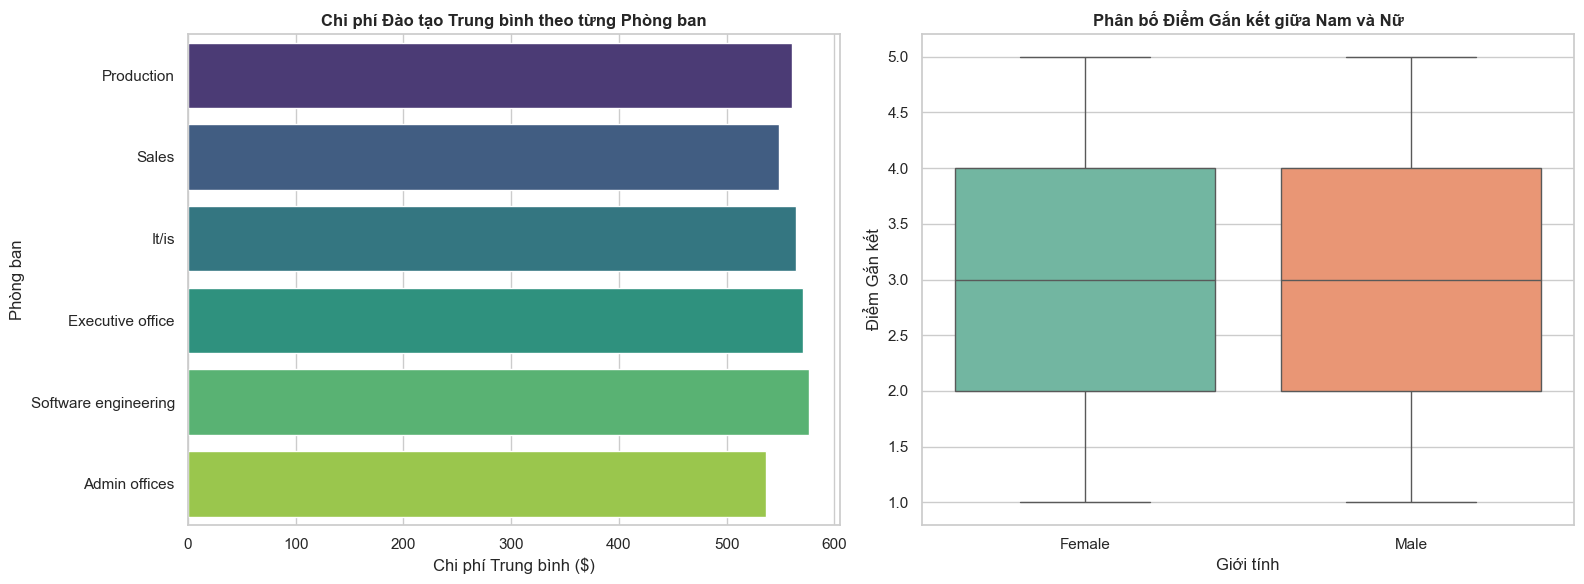

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: So sánh Chi phí đào tạo trung bình giữa các Phòng ban
sns.barplot(
    x='Training Cost', 
    y='DepartmentType', 
    data=df, 
    estimator='mean',     # Tính giá trị trung bình
    ci=None,              # Tắt dải sai số cho gọn
    palette='viridis', 
    ax=axes[0]
)
axes[0].set_title('Chi phí Đào tạo Trung bình theo từng Phòng ban', fontweight='bold')
axes[0].set_xlabel('Chi phí Trung bình ($)')
axes[0].set_ylabel('Phòng ban')

# Biểu đồ 2: So sánh Điểm Gắn kết (Engagement Score) theo Giới tính
sns.boxplot(
    x='GenderCode', 
    y='Engagement Score', 
    data=df, 
    palette='Set2', 
    ax=axes[1]
)
axes[1].set_title('Phân bố Điểm Gắn kết giữa Nam và Nữ', fontweight='bold')
axes[1].set_xlabel('Giới tính')
axes[1].set_ylabel('Điểm Gắn kết')

plt.tight_layout()
plt.show()

- ở đây tổng chi phí đào tạo cao nhất sẽ rơi vào khoảng từ 500 đến 600 trong đó engieering chi phí đạo tạo lớn nhất cũng chỉ hơn 1 chút so với các ban còn lại 
- còn lại ở công ty tỷ lệ nam nữ bình đẳng như nhau không xảy ra mất bình đẳng họ sẽ rơi vào khoảng trung bình 3 điểm gắn kết

### Phân tích dữ liệu theo thời gian

#### 8. Phân tích theo Thời gian (Time-Based Analysis)
Bước đầu tiên: Chuyển đổi các cột Ngày/Tháng sang định dạng `datetime` của Pandas để trích xuất Năm và Tháng.

In [61]:
# Giả sử dữ liệu của bạn có cột Ngày tuyển dụng tên là 'StartDate' hoặc 'HireDate'
# Nếu tên cột của bạn khác, hãy thay chữ 'StartDate' bằng tên cột chính xác nhé.
date_column = 'StartDate' 

if date_column in df.columns:
    # 1. Chép đè cột đó thành định dạng Datetime chuẩn
    df[date_column] = pd.to_datetime(df[date_column])
    
    # 2. Sinh ra 2 cột mới là Năm và Tháng để dễ phân tích
    df['HireYear'] = df[date_column].dt.year
    df['HireMonth'] = df[date_column].dt.month
    
    print("✅ Đã chuyển đổi thành công dữ liệu thời gian!")
    print(df[['Employee ID', date_column, 'HireYear', 'HireMonth']].head())
else:
    print(f"Không tìm thấy cột '{date_column}' trong dữ liệu.")

✅ Đã chuyển đổi thành công dữ liệu thời gian!
   Employee ID  StartDate  HireYear  HireMonth
0         3427 2019-09-20      2019          9
1         3428 2023-02-11      2023          2
2         3429 2018-12-10      2018         12
3         3430 2021-06-21      2021          6
4         3431 2019-06-29      2019          6


C:\Users\Admin\AppData\Local\Temp\ipykernel_9088\3080598341.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_column] = pd.to_datetime(df[date_column])


Cell 9b (Code): Vẽ biểu đồ Xu hướng Tuyển dụng theo Năm (Line Plot)

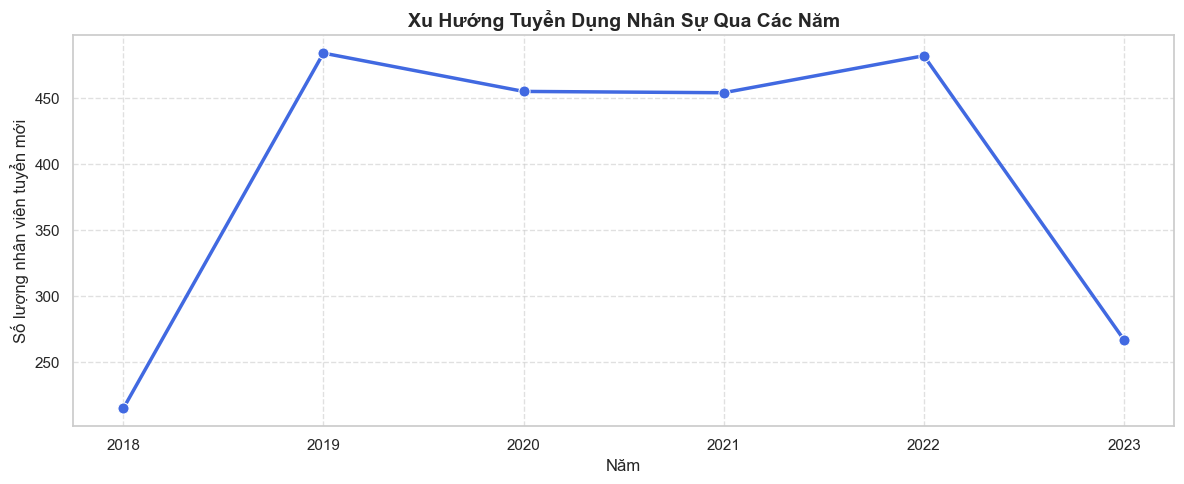

In [62]:
if 'HireYear' in df.columns:
    # Gom nhóm theo Năm và đếm số lượng nhân viên
    yearly_hires = df.groupby('HireYear')['Employee ID'].count().reset_index()
    yearly_hires.columns = ['Năm Tuyển Dụng', 'Số Lượng Nhân Viên Mới']
    
    # Vẽ biểu đồ đường
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=yearly_hires, x='Năm Tuyển Dụng', y='Số Lượng Nhân Viên Mới', 
                 marker='o', color='royalblue', linewidth=2.5, markersize=8)
    
    plt.title('Xu Hướng Tuyển Dụng Nhân Sự Qua Các Năm', fontweight='bold', fontsize=14)
    plt.xlabel('Năm')
    plt.ylabel('Số lượng nhân viên tuyển mới')
    
    # Ép trục X chỉ hiển thị số nguyên (các năm)
    plt.xticks(yearly_hires['Năm Tuyển Dụng'].astype(int))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

- với xu hướng tuyển dụng khi bước vào 2019 đến giao đoạn 2022 thì được ưa chuộng tuyển dụng các nhận sự của các phòng ban quá cao nhưng khi bắt đầu từ 2023 việc tuyển dụng trở lên khó khăn hơn

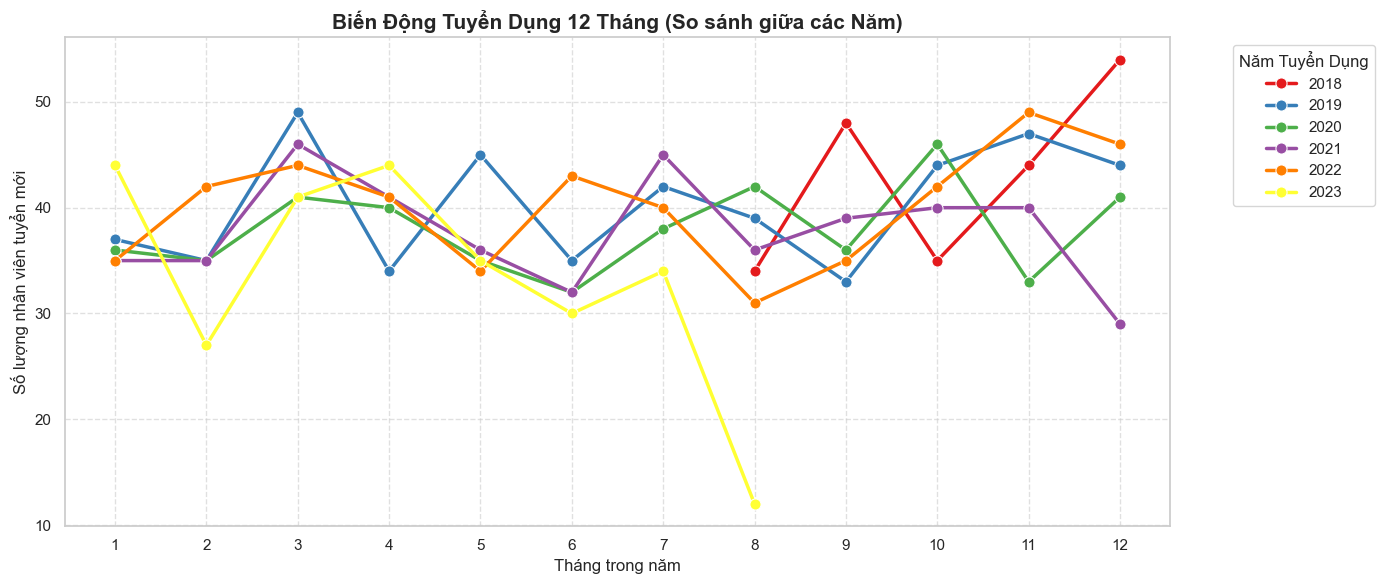

In [63]:
if 'HireYear' in df.columns and 'HireMonth' in df.columns:
    # Gom nhóm theo cả Năm và Tháng
    yearly_monthly_hires = df.groupby(['HireYear', 'HireMonth'])['Employee ID'].count().reset_index()
    yearly_monthly_hires.columns = ['Năm Tuyển Dụng', 'Tháng', 'Số Lượng']
    
    # Vẽ biểu đồ
    plt.figure(figsize=(14, 6))
    
    # X là Tháng (1-12), Hue (màu các đường) là Năm
    sns.lineplot(data=yearly_monthly_hires, x='Tháng', y='Số Lượng', hue='Năm Tuyển Dụng', 
                 marker='o', linewidth=2.5, markersize=8, palette='Set1')
    
    plt.title('Biến Động Tuyển Dụng 12 Tháng (So sánh giữa các Năm)', fontweight='bold', fontsize=15)
    plt.xlabel('Tháng trong năm')
    plt.ylabel('Số lượng nhân viên tuyển mới')
    
    # Ép trục X hiển thị chính xác từ tháng 1 đến tháng 12
    plt.xticks(range(1, 13))
    
    # Xử lý chú thích (Legend)
    plt.legend(title='Năm Tuyển Dụng', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

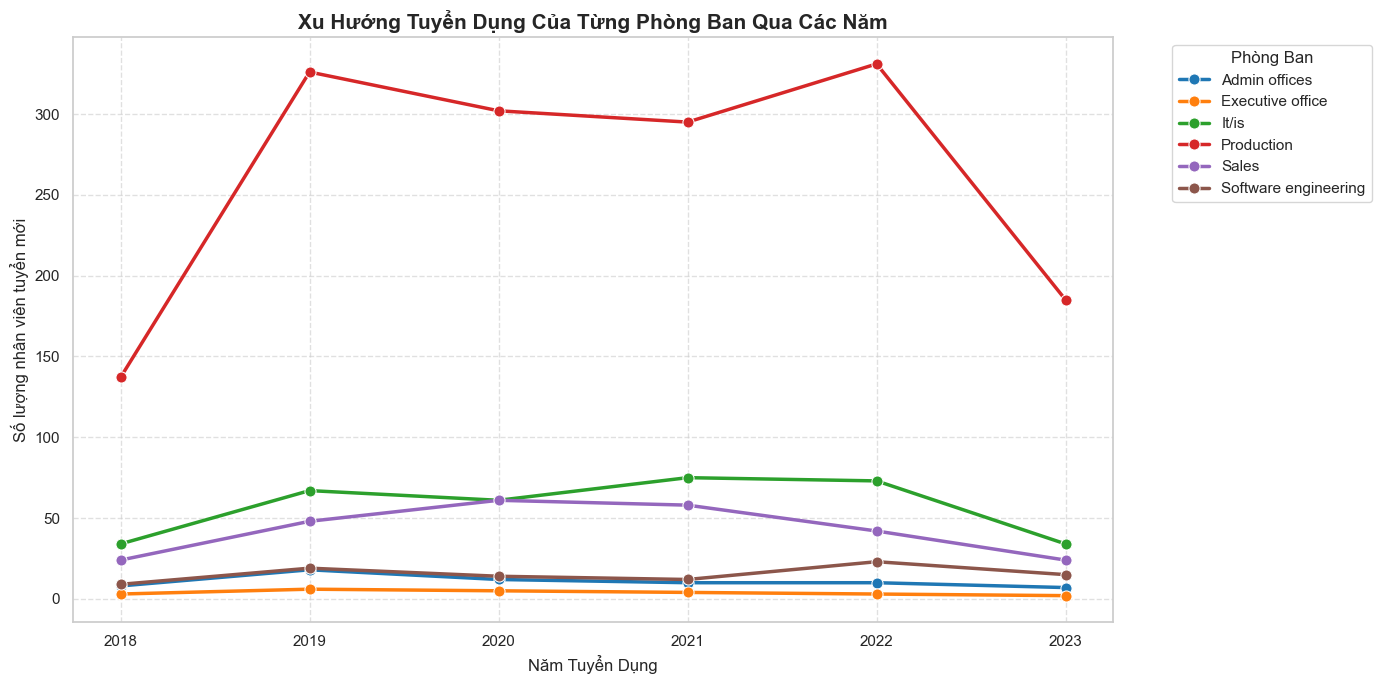

In [64]:
if 'HireYear' in df.columns and 'DepartmentType' in df.columns:
    # Gom nhóm theo cả Cột Năm và Cột Phòng ban
    dept_yearly_hires = df.groupby(['HireYear', 'DepartmentType'])['Employee ID'].count().reset_index()
    dept_yearly_hires.columns = ['Năm Tuyển Dụng', 'Phòng Ban', 'Số Lượng']
    
    # Thiết lập biểu đồ
    plt.figure(figsize=(14, 7))
    
    # Vẽ nhiều đường, dùng thuộc tính 'hue' để phân biệt các phòng ban bằng màu sắc
    sns.lineplot(data=dept_yearly_hires, x='Năm Tuyển Dụng', y='Số Lượng', 
                 hue='Phòng Ban', marker='o', linewidth=2.5, markersize=8, palette='tab10')
    
    plt.title('Xu Hướng Tuyển Dụng Của Từng Phòng Ban Qua Các Năm', fontweight='bold', fontsize=15)
    plt.xlabel('Năm Tuyển Dụng')
    plt.ylabel('Số lượng nhân viên tuyển mới')
    
    # Ép trục X hiển thị số nguyên (Các năm)
    years = dept_yearly_hires['Năm Tuyển Dụng'].unique()
    plt.xticks(years.astype(int))
    
    # Đẩy bảng chú thích (Legend) ra ngoài để không che mất đường biểu đồ
    plt.legend(title='Phòng Ban', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()